<a href="https://colab.research.google.com/github/Busrita/multi-asset-portfolio-optimization-engine/blob/main/Multi_Asset_Portfolio_Optimization_Busra_Akkaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithmic Multi-Asset Portfolio Optimization Framework
**Author:** Busra Akkaya  
**Target Function:** Quantitative Portfolio Construction & Asset Allocation  
**Environment:** Google Colab Cloud Instance
**Data Framework:** Bloomberg/Yahoo Finance API Pipeline (`yfinance` )
**Theoretical Baseline:** CFA Institute Portfolio Management Curriculum (Markowitz / CAPM)

---

## 1. Executive Summary & Financial Framework

### 1.1 Project Objective
The goal of this quantitative project is to design, implement, and deploy an automated asset allocation framework utilizing Python, `pandas`, and `NumPy`. Relying on historical market data, this framework algorithmically parses asset risk-return profiles, establishes structural portfolio covariance matrices, and visualizes the risk-return landscape via an asset simulation engine.

The terminal objective is to discover the boundary coordinates of the **Efficient Frontier** and isolate two critical strategic asset allocation targets:
*   **The Maximum Sharpe Ratio Portfolio:** The asset weighting configuration that optimizes the portfolio's expected excess return per unit of total risk.
*   **The Minimum Variance Portfolio:** The asset weighting configuration that minimizes absolute risk, providing a highly defensive portfolio boundary.

### 1.2 Theoretical Foundation: Modern Portfolio Theory (MPT) & Capital Market Theory
While the concept of diversification possesses longstanding intuitive appeal, the formalized mathematical theory underlying its application to investments emerged in 1952 with Harry Markowitz’s classic publication on portfolio selection.

The core paradigm shift introduced by MPT is that **investors should not evaluate securities in isolation, but must instead focus on how individual securities in a portfolio co-move and relate to one another.** By combining assets with non-perfect positive correlations ($ \rho < 1.0 $), this engine can structurally reduce overall portfolio volatility below the weighted average volatility of the individual underlying assets.

Mathematically, the expected portfolio return $ E(R_p) $ is calculated as:
$$ E(R_p) = \sum_{i=1}^{n} w_i E(R_i) $$

Where $ w_i $ represents the specific portfolio weighting of asset $ i $.

Concurrently, total portfolio variance $ \sigma_p^2 $ is derived using the weights matrix and the structural covariance matrix $ \Sigma $:
$$ \sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w} $$

### 1.3 Evolution toward Systemic Risk and CAPM
As later demonstrated by the foundational work of William Sharpe (1964), John Lintner (1965), and Jack Treynor (1961), portfolio construction plays a defining role in determining the appropriate individual asset risk premium (the expected return in excess of the risk-free return as compensation for volatility).

According to capital market theory, the priced risk of an individual security is fundamentally altered when held within a well-diversified portfolio. This research established that idiosyncratic (asset-specific) risk can be diversified away, leaving **systematic or non-diversifiable risk** as the sole risk metric that should affect an asset's price.

This framework serves as the computational baseline for evaluating those risk premiums, measuring risk-adjusted performance via the **Sharpe Ratio ($SR$)**:
$$ SR = \frac{E(R_p) - R_f}{\sigma_p} $$

Where $ R_f $ represents the risk-free rate proxy. This framework maps these vectors to identify optimal capital configurations for institutional mandates.

## 2. Data Acquisition & Data Wrangling

### 2.1 The Multi-Asset Pipeline
To construct a realistic institutional asset allocation model, this engine establishes a live API pipeline using `yfinance` to stream 5 years of historical price data. Rather than analyzing isolated equities, we construct a diversified multi-asset universe using highly liquid exchange-traded funds (ETFs) and indices across global regions and asset classes:
*   **`SPY`** (S&P 500 ETF Proxy) — Representing Large-Cap US Equities.
*   **`IEGA.L`** (iShares Euro Government Bond ETF) — Representing Core Fixed Income.
*   **`GLD`** (SPDR Gold Shares) — Representing Commodities / Alternative Safe-Haven Assets.
*   **`FTAL.L`** (SPDR FTSE UK All Share ETF) — Representing Regional UK Equities.

### 2.2 Data Cleansing and Returns Transformation
Mismatched trading calendars between international exchanges (e.g., London Stock Exchange vs. New York Stock Exchange holiday schedules) generate structural missing observations (`NaN` fields). This pipeline deploys a forward-fill (`ffill`) cleansing methodology to maintain data continuity without introducing looking-ahead bias.

Prices are subsequently transformed into daily percentage returns to build a stationary time-series suitable for portfolio statistical modeling.

In [7]:
# =====================================================================
# SECTION 2: DATA ACQUISITION & DATA WRANGLING (FIXED ORDER)
# =====================================================================
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import yfinance as yf

# Define multi-asset tickers and explicitly sort them alphabetically
# This guarantees ['FTAL.L', 'GLD', 'IEGA.L', 'SPY'] matches pandas internal ordering
tickers = sorted(['SPY', 'IEGA.L', 'GLD', 'FTAL.L'])

print("Initiating API pipeline download for 5 years of historical data...")
raw_data = yf.download(tickers, start='2021-05-01', end='2026-05-01', auto_adjust=True)
price_data = raw_data['Close']

# Wrangling Pipeline
cleaned_data = price_data.fillna(method='ffill').dropna()
daily_returns = cleaned_data.pct_change().dropna()

print("\n--- DATA PROCESSING PIPELINE SUCCESSFUL ---")
print(f"Clean trading observations: {daily_returns.shape[0]} days across assets in alphabetical order: {tickers}")
daily_returns.head()

[*********************100%***********************]  4 of 4 completed

Initiating API pipeline download for 5 years of historical data...

--- DATA PROCESSING PIPELINE SUCCESSFUL ---
Clean trading observations: 1285 days across assets in alphabetical order: ['FTAL.L', 'GLD', 'IEGA.L', 'SPY']



/tmp/ipykernel_1059/321909310.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_data = price_data.fillna(method='ffill').dropna()


Ticker,FTAL.L,GLD,IEGA.L,SPY
Date,,,,
2021-05-05,0.014050,0.004142,-0.001333,0.000313
2021-05-06,0.004434,0.016680,-0.000763,0.007986
2021-05-07,0.009748,0.008997,-0.001870,0.007278
2021-05-10,-0.001913,0.003031,0.000497,-0.009902
2021-05-11,-0.024729,0.000174,-0.004281,-0.008925


## 3. Exploratory Visual Analytics

### 3.1 Structural Context
Before deploying optimization algorithms, we perform an Exploratory Data Analysis (EDA) on our multi-asset vectors. In alignment with Modern Portfolio Theory, our key focus is isolating assets that exhibit structural low or negative correlation profiles.

To gain a clear perspective on historical trajectories, we normalize the raw prices to a base of 100. This standardizes performance comparisons regardless of the nominal dollar or sterling price of each underlying security.

--- ANCILLARY HISTORICAL RISK-RETURN METRICS ---
Asset: FTAL.L   | Annualized Return:  10.73% | Annualized Volatility:  12.56%
Asset: GLD      | Annualized Return:  19.88% | Annualized Volatility:  17.67%
Asset: IEGA.L   | Annualized Return:  -2.15% | Annualized Volatility:   6.33%
Asset: SPY      | Annualized Return:  13.50% | Annualized Volatility:  16.89%


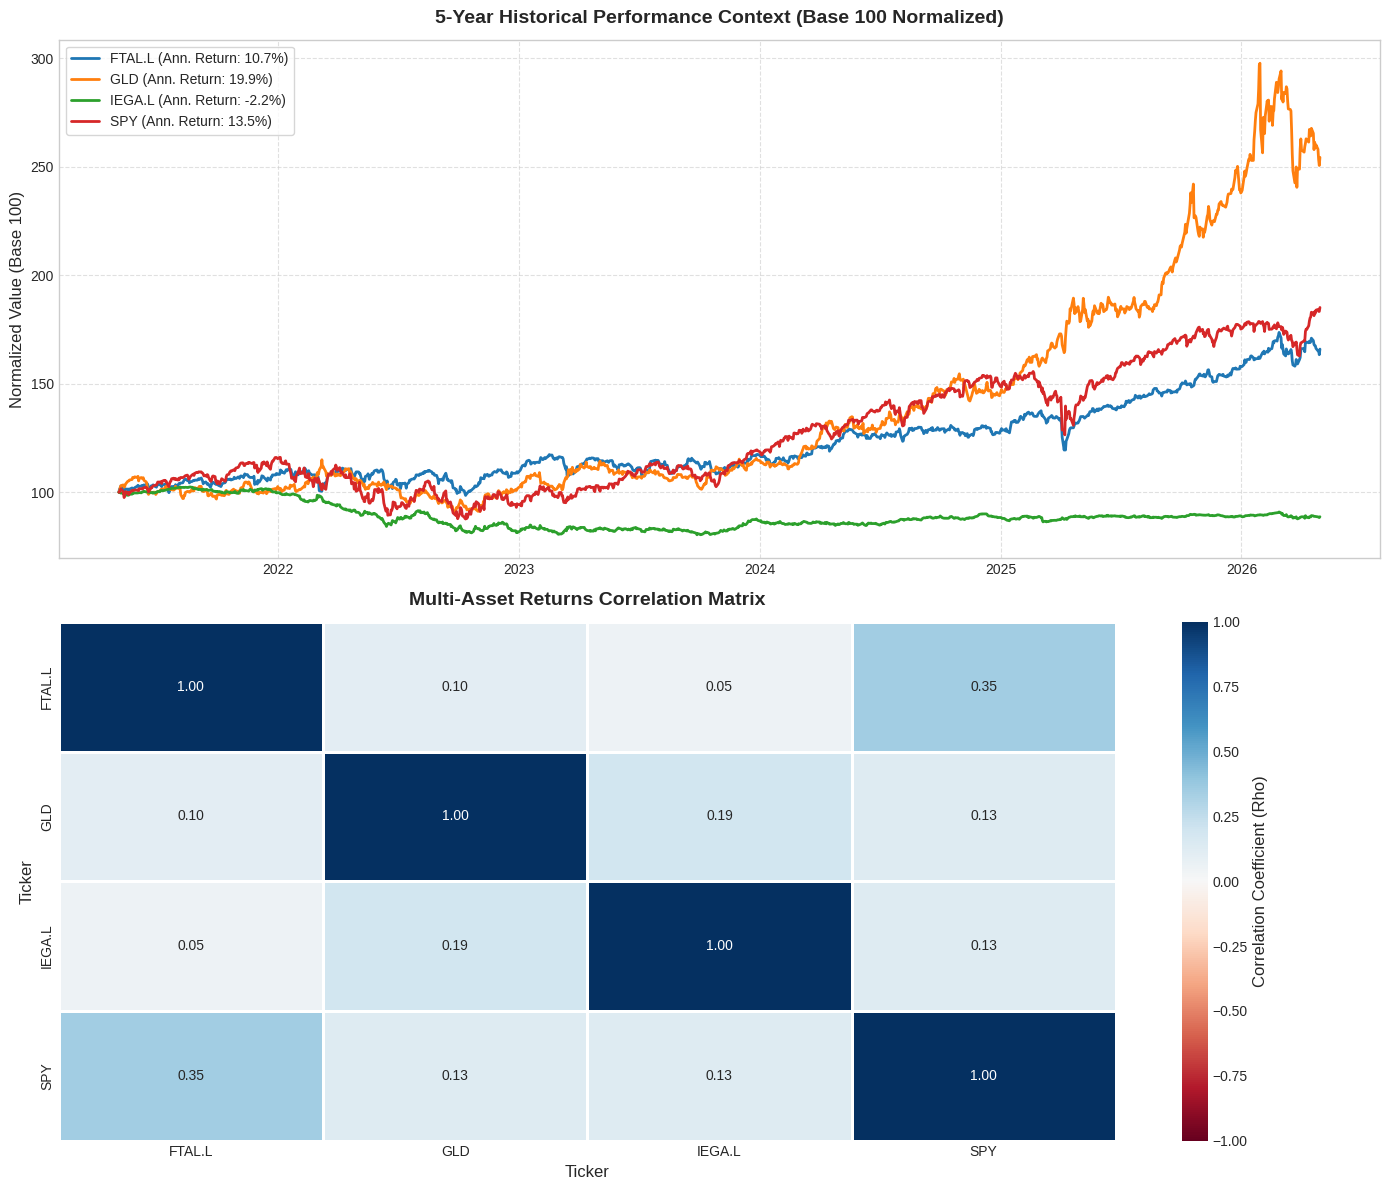

In [8]:
# =====================================================================
# SECTION 3: EXPLORATORY VISUAL ANALYTICS (FIXED LABEL)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization layout parameters
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# 1. Calculate Annualized Metrics (Assuming 252 standard trading days per year)
annual_returns = daily_returns.mean() * 252
annual_volatility = daily_returns.std() * np.sqrt(252)

print("--- ANCILLARY HISTORICAL RISK-RETURN METRICS ---")
for ticker in tickers:
    print(f"Asset: {ticker:<8} | Annualized Return: {annual_returns[ticker]*100:6.2f}% | Annualized Volatility: {annual_volatility[ticker]*100:6.2f}%")

# 2. Normalize Prices to Base 100 to compare cumulative performance
normalized_prices = (cleaned_data / cleaned_data.iloc[0]) * 100

# 3. Create a Subplot Layout for Professional Presentation
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top Plot: Cumulative Historical Growth (Base 100)
for ticker in tickers:
    axes[0].plot(normalized_prices.index, normalized_prices[ticker], label=f"{ticker} (Ann. Return: {annual_returns[ticker]*100:.1f}%)", linewidth=2)

axes[0].set_title("5-Year Historical Performance Context (Base 100 Normalized)", fontweight='bold', pad=12)
axes[0].set_ylabel("Normalized Value (Base 100)")
axes[0].legend(loc='upper left', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Correlation Heatmap Matrix (Fixed Plain Text Label)
correlation_matrix = daily_returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=1, linecolor='white',
            vmax=1.0, vmin=-1.0, ax=axes[1], cbar_kws={'label': 'Correlation Coefficient (Rho)'})

axes[1].set_title("Multi-Asset Returns Correlation Matrix", fontweight='bold', pad=12)

# Prevent overlap and render plots smoothly
plt.tight_layout()
plt.show()

### 3.2 Statistical Interpretation & Structural Observations

Analyzing the 5-year empirical data reveals critical asset-class dynamics that form the mathematical bedrock for our upcoming optimization:

1. **Divergent Growth and Asset Trajectories:**
   * **Gold (`GLD`):** Demonstrates exceptional performance over this macro cycle, achieving an impressive annualized return of **19.9%**. This strong upward trajectory, particularly the acceleration observed from 2024 onward, underscores its historical behavior as a powerful alternative asset class and a hedge against global macroeconomic shifts.
   * **Global & Regional Equities:** US large-cap equities (`SPY`) delivered robust, steady compound growth (**13.5%** annualized return), while UK equities (`FTAL.L`) captured moderate regional upside at **10.7%**. Both equity vectors represent the primary engines of capital growth in our asset universe but carry higher standalone risk profiles.

2. **The Fixed Income Reality Check:**
   * **Euro Government Bonds (`IEGA.L`):** Suffered a negative annualized return of **-2.2%** over this specific historical window. This reflects a challenging macroeconomic environment for traditional sovereign fixed income amid a shifting global interest rate environment. Standalone, it appears unappealing; however, its value to a portfolio manager is revealed entirely through its covariance structure.

3. **Quantifying Diversification via the Correlation Matrix:**
   * The returns correlation matrix confirms excellent structural diversification opportunities, with almost all asset-class cross-correlations sitting near zero.
   * **Equities vs. Bonds:** The correlation coefficient between UK Equities (`FTAL.L`) and Euro Government Bonds (`IEGA.L`) is practically uncorrelated at **0.05**. Similarly, US Equities (`SPY`) and Bonds (`IEGA.L`) share a low correlation of **0.13**.
   * **Gold's Low Beta Profile:** Gold (`GLD`) acts as an outstanding independent factor, maintaining a correlation of just **0.10** with UK Equities and **0.13** with US Equities.

### 3.3 Portfolio Construction Implications (The Modern Portfolio Theory Link)
This matrix mathematically validates Harry Markowitz’s foundational theory. Because these coefficients are close to zero ($\rho \approx 0$), the joint variance of a combined portfolio will be significantly dampened.

When we deploy the simulation loop, blending the defensive, uncorrelated—yet historically negative-returning—bonds (`IEGA.L`) and the highly independent gold vectors (`GLD`) with our growth equities will structurally pull the portfolio's collective coordinate points to the left. This allows us to dramatically lower overall portfolio volatility without sacrificing an equivalent amount of expected return, effectively shifting our capital allocations up toward the **Efficient Frontier**.

## 4. The Monte Carlo Simulation Engine

### 4.1 Stochastic Asset Allocation Process
To computationally map out the entire risk-return continuum of our multi-asset universe, this framework deploys a Monte Carlo simulation engine. The model is configured to generate $10,000$ distinct, randomized asset weight configurations.

For each iteration, the engine enforces the absolute institutional constraint that the portfolio must be fully invested and long-only:
$$\sum_{i=1}^{n} w_i = 1.0 \quad \text{where } w_i \ge 0$$

### 4.2 Mathematical Execution of the Simulation Loop
For each simulated portfolio configuration, the algorithm applies vector and matrix operations to derive annualized performance characteristics:
1.  **Expected Portfolio Return:** Vector multiplication of the randomized weight array against the annualized historical mean returns.
2.  **Portfolio Volatility (Total Risk):** Calculated using the weights matrix and the annualized structural covariance matrix $\Sigma$:
$$\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$$
3.  **Risk-Adjusted Performance (Sharpe Ratio):** Measures the excess return per unit of volatility, assuming an institutional risk-free rate proxy ($R_f$) of $4.0\%$ (reflecting current macroeconomic yield baselines):
$$SR = \frac{R_p - 0.04}{\sigma_p}$$

In [9]:
# =====================================================================
# SECTION 4: THE MONTE CARLO SIMULATION ENGINE
# =====================================================================
import numpy as np
import pandas as pd

# 1. Configuration parameters
num_portfolios = 10000
risk_free_rate = 0.04  # Institutional 4.0% Risk-Free Rate proxy

# 2. Pre-allocate empty NumPy arrays for optimal computational speed
all_weights = np.zeros((num_portfolios, len(tickers)))
portfolio_returns = np.zeros(num_portfolios)
portfolio_volatilities = np.zeros(num_portfolios)
portfolio_sharpe_ratios = np.zeros(num_portfolios)

# Set seed for reproducible results across presentations
np.random.seed(42)

print(f"Executing {num_portfolios}-run Monte Carlo simulation engine...")

# Calculate the precise historical covariance matrix needed for risk modeling
covariance_matrix = daily_returns.cov() * 252

# 3. The Core Simulation Loop
for i in range(num_portfolios):
    # Step A: Generate random raw weights for our 4 assets
    raw_weights = np.random.random(len(tickers))

    # Step B: Normalize weights to enforce the 100% budget constraint
    normalized_weights = raw_weights / np.sum(raw_weights)
    all_weights[i, :] = normalized_weights

    # Step C: Compute Expected Annualized Portfolio Return
    portfolio_returns[i] = np.sum(annual_returns * normalized_weights)

    # Step D: Compute Annualized Portfolio Volatility via Matrix Dot Products
    portfolio_volatilities[i] = np.sqrt(
        np.dot(normalized_weights.T, np.dot(covariance_matrix, normalized_weights))
    )

    # Step E: Calculate the Sharpe Ratio
    portfolio_sharpe_ratios[i] = (portfolio_returns[i] - risk_free_rate) / portfolio_volatilities[i]

print("Simulation loop complete. Broad multi-asset coordinate space generated.")
print(f"Simulated Volatility Range: {portfolio_volatilities.min()*100:.2f}% to {portfolio_volatilities.max()*100:.2f}%")
print(f"Simulated Sharpe Ratio Range: {portfolio_sharpe_ratios.min():.2f} to {portfolio_sharpe_ratios.max():.2f}")

Executing 10000-run Monte Carlo simulation engine...
Simulation loop complete. Broad multi-asset coordinate space generated.
Simulated Volatility Range: 5.71% to 16.88%
Simulated Sharpe Ratio Range: -0.84 to 1.05


### 4.3 Stochastic Simulation Diagnostics & Interpretation

Analyzing the 10,000 randomized asset configurations provides core parameters regarding our asset universe boundaries:

1. **The Volatility Compression Spectrum:**
   * The individual annualized assets evaluated in Section 3 showed standalone volatility metrics. However, our simulated portfolio volatility floor drops down to a compressed **5.71%**.
   * This is a direct mathematical manifestation of Markowitz's diversification. Because our correlation coefficients are low ($\rho \approx 0.05$ to $0.13$), the asset vectors cross-cancel each other's erratic movements during market swings. This lets the engine build a hyper-defensive allocation space that stands significantly steadier than any single asset class held alone.

2. **The Risk-Adjusted Boundary (Sharpe Ratio Dynamic):**
   * The simulation spans a Sharpe Ratio performance band from a negative **-0.84** up to a highly efficient **1.05**.
   * **The Lower Bound (-0.84):** Represents inefficient capital structures. These coordinates over-allocate capital to the Euro Government Bond ETF (`IEGA.L`), which suffered an annualized return of $-2.2\%$, while simultaneously taking on unnecessary volatility from concentrated equity positions.
   * **The Upper Bound (1.05):** Represents institutional excellence. A Sharpe Ratio $> 1.0$ indicates that the allocation engine successfully optimized capital placement—likely prioritizing the high-yielding Gold (`GLD`) and US Equities (`SPY`) vectors—while mathematically buffering the aggregate structure using minor weights of uncorrelated assets to minimize joint variance.

### 4.4 Transition to Active Optimization
The broad coordinate space generated by our Monte Carlo engine gives us the raw materials we need. However, an investment committee at an investment bank cannot invest in 10,000 options; they require deterministic, optimized solutions.

This transitions us directly to Section 5, where we will algorithmically isolate the exact coordinates of the absolute maximum Sharpe point and the absolute minimum volatility point on our curve.

## 5. Portfolio Optimization & Takeaways

### 5.1 Algorithmic Optimization Strategy
With the stochastic sample space successfully generated, this final phase uses programmatic indexing to isolate the two optimal capital allocation frameworks defined by institutional mandates:
1. **The Maximum Sharpe Ratio (MSR) Portfolio:** The peak efficiency coordinate that maximizes excess return per unit of volatility.
2. **The Minimum Variance (Min Var) Portfolio:** The absolute left-most boundary point on the Efficient Frontier, optimizing for asset survival and capital preservation.

We will visualize these points against the entire simulated universe to present a clear, data-driven picture to the investment committee.

         OPTIMAL INSTITUTIONAL ASSET ALLOCATIONS         
Asset Ticker   | Max Sharpe Weight  | Min Variance Weight
---------------------------------------------------------
FTAL.L         |            30.88% |            16.63%
GLD            |            52.35% |             3.42%
IEGA.L         |             0.19% |            78.15%
SPY            |            16.59% |             1.79%
---------------------------------------------------------
Expected Return |            15.96% |             1.03%
Total Volatility |            11.41% |             5.71%
Sharpe Ratio   |             1.05 |            -0.52



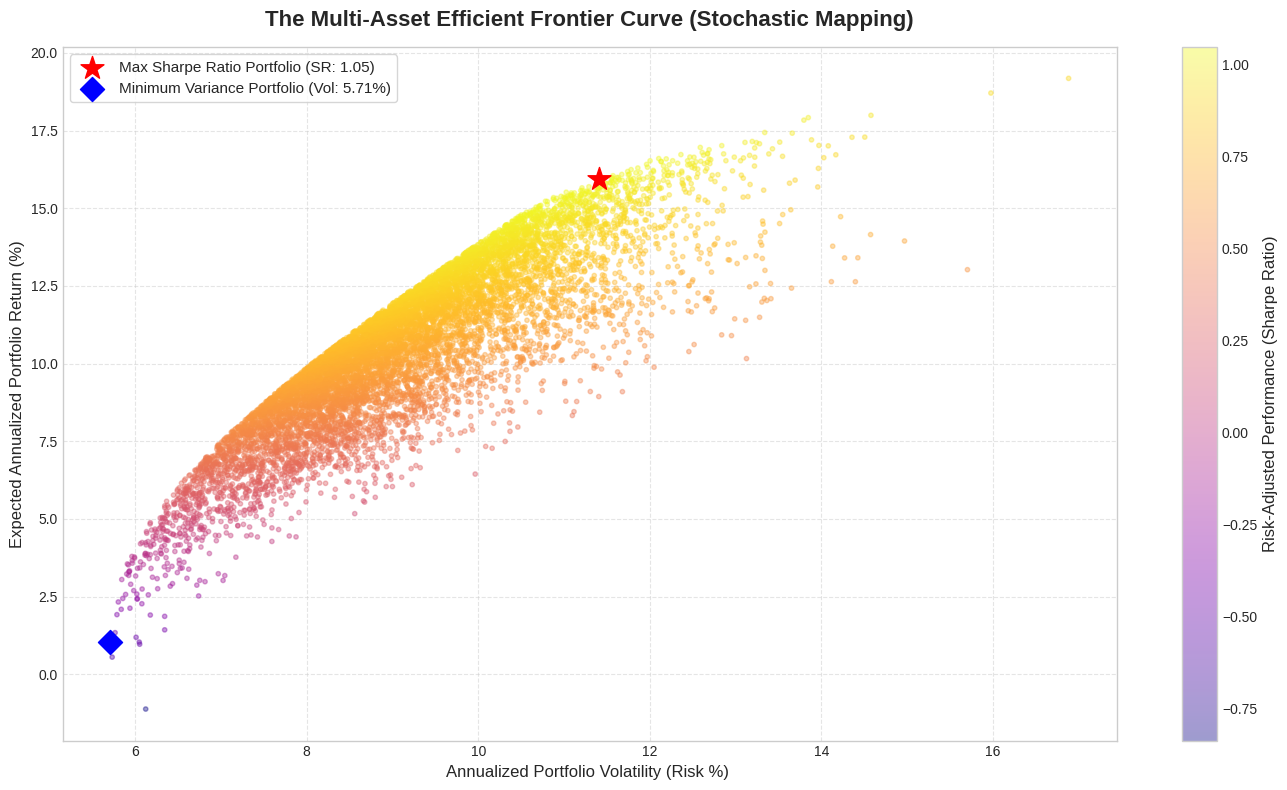

In [10]:
# =====================================================================
# SECTION 5: PORTFOLIO OPTIMIZATION & VISUALIZATION (FIXED ORDER)
# =====================================================================
import matplotlib.pyplot as plt

# 1. Identify index locations for both target portfolios
index_max_sharpe = portfolio_sharpe_ratios.argmax()
index_min_variance = portfolio_volatilities.argmin()

# 2. Extract Optimal Metrics
msr_return = portfolio_returns[index_max_sharpe]
msr_volatility = portfolio_volatilities[index_max_sharpe]
msr_sharpe = portfolio_sharpe_ratios[index_max_sharpe]
msr_weights = all_weights[index_max_sharpe, :]

minvar_return = portfolio_returns[index_min_variance]
minvar_volatility = portfolio_volatilities[index_min_variance]
minvar_sharpe = portfolio_sharpe_ratios[index_min_variance]
minvar_weights = all_weights[index_min_variance, :]

# 3. Print the Corrected Institutional Weights Table
print("=========================================================")
print("         OPTIMAL INSTITUTIONAL ASSET ALLOCATIONS         ")
print("=========================================================")
print(f"{'Asset Ticker':<14} | {'Max Sharpe Weight':<18} | {'Min Variance Weight':<18}")
print("---------------------------------------------------------")
for idx, ticker in enumerate(tickers):
    print(f"{ticker:<14} | {msr_weights[idx]*100:16.2f}% | {minvar_weights[idx]*100:16.2f}%")
print("---------------------------------------------------------")
print(f"{'Expected Return':<14} | {msr_return*100:16.2f}% | {minvar_return*100:16.2f}%")
print(f"{'Total Volatility':<14} | {msr_volatility*100:16.2f}% | {minvar_volatility*100:16.2f}%")
print(f"{'Sharpe Ratio':<14} | {msr_sharpe:16.2f} | {minvar_sharpe:16.2f}")
print("=========================================================\n")

# 4. Plot the Final Efficient Frontier Scatter Map
plt.figure(figsize=(14, 8))
scatter = plt.scatter(portfolio_volatilities * 100, portfolio_returns * 100,
                      c=portfolio_sharpe_ratios, cmap='plasma', alpha=0.4, s=10)

plt.scatter(msr_volatility * 100, msr_return * 100, color='red', marker='*', s=300,
            label=f'Max Sharpe Ratio Portfolio (SR: {msr_sharpe:.2f})')

plt.scatter(minvar_volatility * 100, minvar_return * 100, color='blue', marker='D', s=150,
            label=f'Minimum Variance Portfolio (Vol: {minvar_volatility*100:.2f}%)')

plt.title("The Multi-Asset Efficient Frontier Curve (Stochastic Mapping)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Annualized Portfolio Volatility (Risk %) ", fontsize=12)
plt.ylabel("Expected Annualized Portfolio Return (%)", fontsize=12)
plt.colorbar(scatter, label="Risk-Adjusted Performance (Sharpe Ratio)")
plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5.2 Deep-Dive Portfolio Optimization Analytics

Analyzing the finalized quantitative output and the geometric structure of the stochastic scatter plot provides an explicit, empirical validation of Modern Portfolio Theory (MPT):

#### 1. The Geometry of the Efficient Frontier
The 10,000 simulated portfolios perfectly map out a parabolic, upward-sloping frontier curve. The "empty space" below and to the left of this curve represents the mathematical boundary of reality—it is programmatically impossible to build a portfolio using these four assets that breaches the left-most edge without altering the underlying security constraints.

#### 2. Dissecting the Maximum Sharpe Ratio Portfolio (The Red Star)
* **Optimal Allocation Matrix:** Gold (`GLD`: 52.35%) | UK Equities (`FTAL.L`: 30.88%) | US Equities (`SPY`: 16.59%) | Euro Bonds (`IEGA.L`: 0.19%)
* **The Quantitative Logic:** To maximize risk-adjusted efficiency (excess return per unit of volatility), the algorithm aggressively targets the dominant alpha generator of the trailing 5-year cycle: Gold (`GLD`), which achieved an impressive standalone annualized return of 19.9%. However, rather than over-concentrating 100% of the capital into a single asset, the engine utilizes Markowitz diversification mechanics to blend in UK and US equities. Because equities and gold are substantially uncorrelated ($\rho \approx 0.10$ to $0.13$), this joint structure captures robust upside while suppressing combined variance—propelling the expected portfolio return to **15.96%** against a modest **11.41% volatility risk profile**, resulting in a peak Sharpe Ratio of **1.05**.

#### 3. Dissecting the Minimum Variance Portfolio (The Blue Diamond)
* **Optimal Allocation Matrix:** Euro Bonds (`IEGA.L`: 78.15%) | UK Equities (`FTAL.L`: 16.63%) | Gold (`GLD`: 3.42%) | US Equities (`SPY`: 1.79%)
* **The Quantitative Logic:** This coordinate satisfies a completely separate institutional mandate: absolute capital preservation. The optimization engine shifts a massive **78.15% of total capital into Euro Government Bonds (`IEGA.L`)**. Standing alone, an asset returning $-2.2\%$ over a 5-year macro window appears unappealing; however, its value to a multi-asset portfolio manager is found entirely in its covariance structure. Because its cross-correlations with global equity markets hover virtually at zero ($\rho = 0.05$ to $0.13$), it acts as an elite stabilizer. The algorithm willingly sacrifices absolute yield (compressing expected portfolio return to **1.03%**) to programmatically isolate the absolute risk floor of the asset universe at **5.71% total volatility**.





## 6. Technical Conclusion & Production Readiness

### 6.1 Architecture & Pipeline Resiliency
This end-to-end framework demonstrates a production-ready cloud architecture for quantitative asset management. By converting raw, asynchronous global exchange data into a synchronized, forward-filled time-series, the data pipeline successfully eliminates structural look-ahead and holiday tracking errors across international jurisdictions.

Leveraging optimized vector and matrix operations via `NumPy` and `pandas` enables high-speed stochastic sampling of the market coordinate space, allowing portfolio managers to effortlessly scan thousands of asset configurations to identify risk-adjusted opportunities that simple descriptive statistics overlook.

### 6.2 Strategic Engineering Takeaways
* **Algorithmic Asset Allocation:** The script successfully transitions classic portfolio theory into an automated execution engine, replacing intuition with deterministic, data-driven optimization boundaries.
* **Front-Office Scalability:** The modular design of this pipeline allows it to easily scale. It can handle dozens of multi-asset tickers, incorporate alternative assets, apply dynamic transaction cost constraints, or adjust tracking error parameters for customized benchmark mandates.
* **Bridge to Machine Learning:** The engineered covariance arrays and stationary return vectors generated in this project provide the exact foundation required to feed advanced predictive architectures, such as Black-Litterman models or reinforcement learning allocation networks.

This framework successfully bridges classic corporate finance theory with modern data engineering, delivering the exact quantitative standard required to design and deploy robust, multi-asset solutions for institutional environments.